### 시계열 분석 : 시간에 따른 추세나 패턴을 파악하여 미래 예측
### 회귀 분석 : 변수들간의 관계를 파악하여 결과를 예측

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#market-price.csv 읽기
df = pd.read_csv('market-price.csv',header=0, names=['day','price'])
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   day     365 non-null    str    
 1   price   365 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


,day,price
0,2017-08-27 00:00:00,4354.308333
1,2017-08-28 00:00:00,4391.673517
2,2017-08-29 00:00:00,4607.985450
3,2017-08-30 00:00:00,4594.987850
4,2017-08-31 00:00:00,4748.255000


In [6]:
# day 컬럼을 날짜형으로 변경하기
df['day'] = pd.to_datetime(df['day'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     365 non-null    datetime64[us]
 1   price   365 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.8 KB


In [7]:
df.describe()

,day,price
count,365,365.000000
mean,2018-02-25 00:00:00,8395.863578
min,2017-08-27 00:00:00,3319.630000
25%,2017-11-26 00:00:00,6396.772500
50%,2018-02-25 00:00:00,7685.633333
75%,2018-05-27 00:00:00,9630.136277
max,2018-08-26 00:00:00,19498.683333
std,NaN,3239.804756


In [8]:
#set_index() :day 컬럼을 인덱스로 변경하기
df = df.set_index('day')
df.head()

,price
day,
2017-08-27,4354.308333
2017-08-28,4391.673517
2017-08-29,4607.985450
2017-08-30,4594.987850
2017-08-31,4748.255000


In [9]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 365 entries, 2017-08-27 to 2018-08-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


<Axes: xlabel='day'>

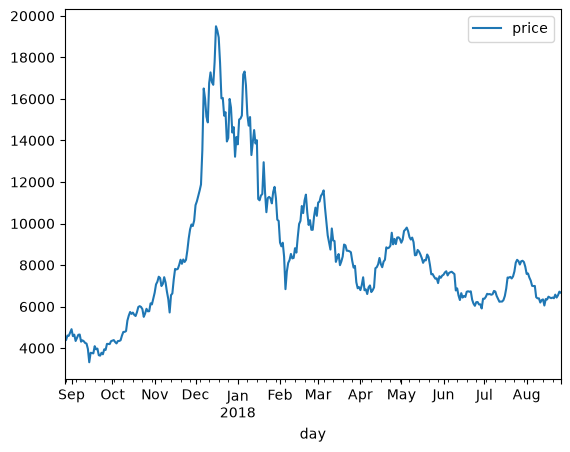

In [10]:
#그래프 출력
df.plot()

In [11]:
# ARIMA 알고리즘 : 시계열 분석을 위한 알고리즘 statsmodels 모듈이 필요
!pip3 install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 33.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [statsmodels] [statsmodels]


In [ ]:
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.arima.model import ARIMA
# df.price.values : 데이터
# order=(2,1,2) 
'''
  AR : 차수. Auto-Regressive(자기회귀). 과거 2개의 기점의 값을 현재 값 예측
  Difference : Integrated(차분) : 현재값 - 직전값
  MA : Moving Average(이동평균) : 과거 2개 시점의 예측 오차(잔차) 현재 값에 추정
'''
model = ARIMA(df.price.values,order=(2,1,2))
model_fit = model.fit()  #학습하기
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2787.490
Date:                Tue, 22 Sep 2026   AIC                           5584.980
Time:                        10:04:11   BIC                           5604.466
Sample:                             0   HQIC                          5592.725
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2418      0.305      0.793      0.428      -0.356       0.839
ar.L2          0.6071      0.200      3.036      0.002       0.215       0.999
ma.L1         -0.1513      0.306     -0.494      0.6

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


### P>|z| : p-value : 0.05 미만인 경우 유의미하다고 판단함

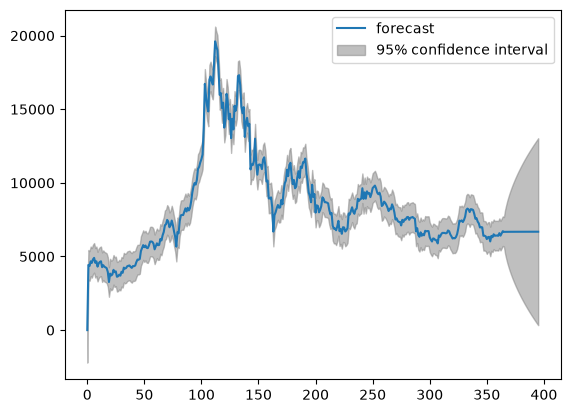

In [15]:
plot_predict(model_fit,start=0,end=len(df) + 30)
plt.show()

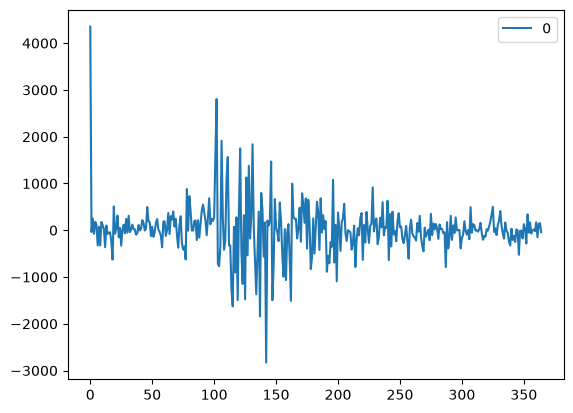

In [16]:
residuals = pd.DataFrame(model_fit.resid) #resid : 잔차 정보
residuals.plot()
plt.show()

In [20]:
#예측 데이터
forecast_data = model_fit.forecast(steps=5) #5일 정보를 예측
forecast_data  #예측 데이터

array([6672.47256746, 6674.47228659, 6674.46916311, 6675.68248335,
       6675.9739762 ])

In [21]:
#market_price-test.csv 파일을 읽어 실데이터와 비교하기
test_df = pd.read_csv('market-price-test.csv',names=['ds','y'],header=0)
test_df

,ds,y
0,2018-08-27 00:00:00,6719.266154
1,2018-08-28 00:00:00,7000.040000
2,2018-08-29 00:00:00,7054.276429
3,2018-08-30 00:00:00,6932.662500
4,2018-08-31 00:00:00,6981.946154


In [ ]:
forecast_obj = model_fit.get_forecast(steps=len(test_df))
pred_y = forecast_obj.predicted_mean #예측된 값
conf_int = forecast_obj.conf_int() # 신뢰구간 [하한값, 상한값]
print(pred_y)
print(conf_int)

[6672.47256746 6674.47228659 6674.46916311 6675.68248335 6675.9739762 ]
[[5668.40696567 7676.53816925]
 [5188.84359169 8160.10098149]
 [4853.28915054 8495.64917569]
 [4548.85008386 8802.51488285]
 [4288.74822068 9063.19973172]]


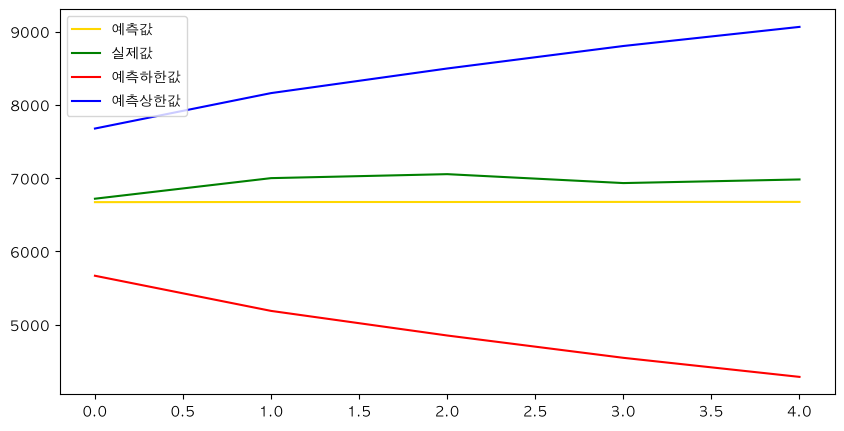

In [29]:
plt.rc('font', family='AppleGothic')
test_y = test_df.y.values #실제 데이터
pred_y_lower = conf_int[:,0] #하한값
pred_y_upper = conf_int[:,1] #상한값
plt.figure(figsize=(10, 5))
plt.plot(pred_y, color='gold',label='예측값')
plt.plot(test_y, color='green',label='실제값')
plt.plot(pred_y_lower, color='red',label='예측하한값')
plt.plot(pred_y_upper, color='blue',label='예측상한값')
plt.legend()
plt.show()

In [ ]:
# prophet 알고리즘으로 시계열 분석하기. 
# 메타에서 만든 알고리즘. 

!pip3 install prophet

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet 

In [ ]:
df = pd.read_csv('market-price.csv', names=['ds','y'],header=0)
df.head()

In [ ]:
prophet = Prophet(seasonality_mode='multiplicative',   #계절성 반영 방식. 곱셈모델로 설정. addtive(덧셈방식)
                  yearly_seasonality=False,            #연간 계절성 설정.
                  weekly_seasonality=True,             #월간 계절성 설정
                  daily_seasonality=True,              #일간 계절성 설정
                  changepoint_prior_scale=0.5)         #0.5정도 트렌드 변화성 감지. 기본:0.05 민감도가 높게 설정함
prophet.fit(df)  #학습하기

11:17:04 - cmdstanpy - INFO - Chain [1] start processing
11:17:04 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# 5일 앞을 예측하기
# 예측된 데이터까지 붙여서 새로운 데이터 프레임 생성. 
# freq='d' : 일자단위. w/y/m : 주/년/월
future_data = prophet.make_future_dataframe(periods=5,freq='d')
future_data

In [37]:
forecast_data = prophet.predict(future_data)
print(forecast_data.shape)
forecast_data.info()

(370, 19)
<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          370 non-null    datetime64[us]
 1   trend                       370 non-null    float64       
 2   yhat_lower                  370 non-null    float64       
 3   yhat_upper                  370 non-null    float64       
 4   trend_lower                 370 non-null    float64       
 5   trend_upper                 370 non-null    float64       
 6   daily                       370 non-null    float64       
 7   daily_lower                 370 non-null    float64       
 8   daily_upper                 370 non-null    float64       
 9   multiplicative_terms        370 non-null    float64       
 10  multiplicative_terms_lower  370 non-null    float64       
 11  multiplicative_terms_upper  370 non-null    float64       


In [40]:
forecast_data[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
365,2018-08-27,6948.175883,6117.962913,7790.471716
366,2018-08-28,6967.062487,6164.453864,7843.516944
367,2018-08-29,6911.501491,6065.923343,7720.514694
368,2018-08-30,6916.770321,6045.266985,7749.377746
369,2018-08-31,6976.466809,6129.092190,7924.655644


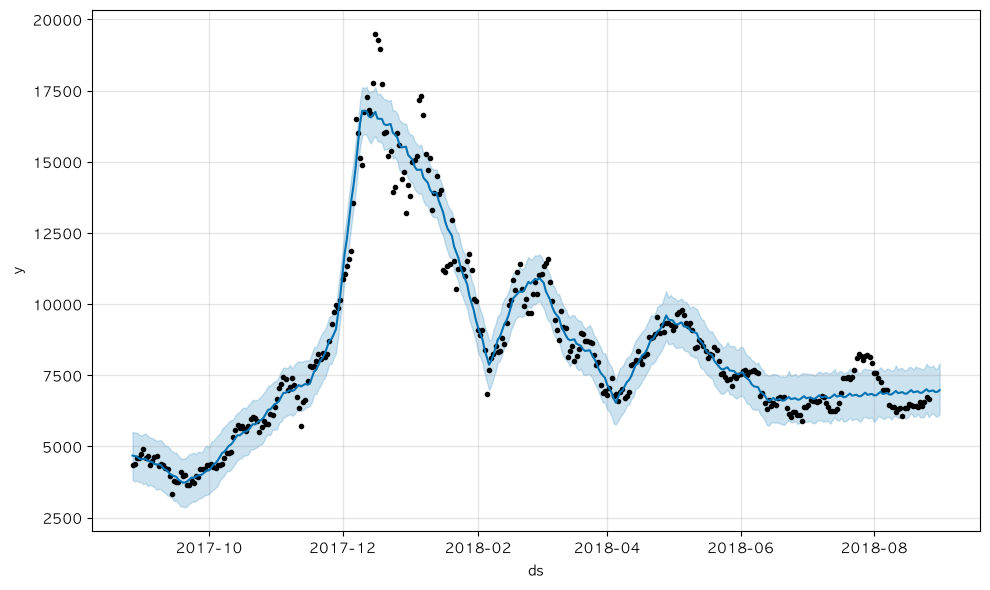

In [41]:
fig1 = prophet.plot(forecast_data)

In [ ]:
fig2 = prophet.plot_components(forecast_data)

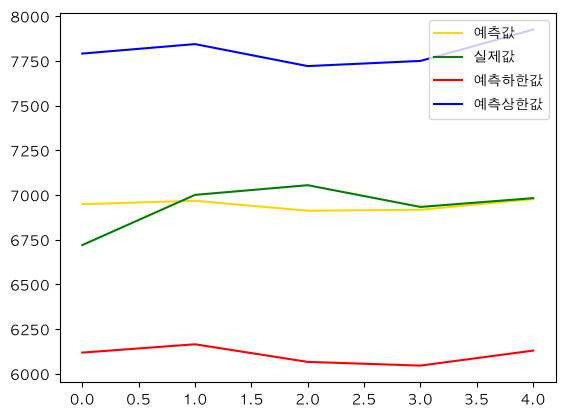

In [47]:
#실데이터 읽기
df_test = pd.read_csv('market-price-test.csv',names=['ds','y'],header=0)
y = test_df.y.values
y_pred = forecast_data.yhat.values[-5:]
y_pred_lower = forecast_data.yhat_lower.values[-5:]
y_pred_upper = forecast_data.yhat_upper.values[-5:]
plt.plot(y_pred,color='gold', label='예측값')
plt.plot(y,color='green',label='실제값')
plt.plot(y_pred_lower, color='red',label='예측하한값')
plt.plot(y_pred_upper, color='blue',label='예측상한값')
plt.legend()

In [ ]:
# 맛집 리뷰 데이터 분석하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re #정규식

In [49]:
df = pd.read_csv("review_data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   score   374 non-null    int64
 1   review  307 non-null    str  
 2   y       374 non-null    int64
dtypes: int64(2), str(1)
memory usage: 8.9 KB


In [50]:
# review가 결측값인 행을 삭제하기
df = df.dropna(subset=['review'],axis=0)
df.info()

<class 'pandas.DataFrame'>
Index: 307 entries, 0 to 372
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   score   307 non-null    int64
 1   review  307 non-null    str  
 2   y       307 non-null    int64
dtypes: int64(2), str(1)
memory usage: 9.6 KB


In [54]:
#한글 이외의 글자는 전부 제거하기
def text_cleaning(text) :
    '''
       ^ : NOT
        ㄱ-ㅣ가-힣]+ : ㄱ 에서 모음 ㅣ(이)까지 가 부터 한글끝까지 문자 여러개(1개 이상)
    '''
    hangul = re.compile('[^ ㄱ-ㅣ가-힣]+') #NOT ( 공백 + 한글 )
    result = hangul.sub('',text) # 공백과 한글을 제외한 문자들을 빈문자열로 치환. 제거
    return result
print(text_cleaning('abc가나다라123 마바사아 456  ** 자차 !!! '))

가나다라 마바사아    자차  


In [55]:
df['ko_text'] = df['review'].apply(lambda x : text_cleaning(str(x)))
df['ko_text'].head()

0    예약할 때는 룸을 주기로 하고 홀을 주고 덥고 직원들이 정신이 없어 그 가격에 내가...
1    점심식사 잘했던곳후식커피한잔 하기도 좋고 주차가능합니다 음식 맛있고 직원분 친절하여...
2                                                     
3                                               녹는다 녹아
5                                   흠잡을곳 없는 반찬이 정갈합니다 
Name: ko_text, dtype: str

In [ ]:
df.info()

In [ ]:
#ko_text 컬럼의 문자열의 길이가 한글자 이상 있는 레코드만 선택하여 df에 저장하기
df = df[df['ko_text'].str.len() > 0]
print(df.head())
df.info()

In [ ]:
# 형태소 분석 : konlpy (Korean Natural Language Processing in Python) => 자바모듈사용. JAVA_HOME 환경에 자바가 존재해야함.
#            kiwipiepy : 한국어형태소 분석기 => 이 모듈을 사용     
# NLP : 자연어 처리

In [ ]:
!pip3 install kiwipiepy

In [ ]:
from kiwipiepy import Kiwi
kiwi = Kiwi()
tokens = kiwi.tokenize("안녕하세요. 형태소 분석 테스트 입니다.")
#token.form : 토큰값. 단어. 내용
#token.tag : 품사
parsed_result = [(token.form,token.tag) for token in tokens]
print(parsed_result)
'''
  NNG : 일반명사, NNP:고유명사, NP:대명사
  XSA.. :  접미사
  EF : 종결어미 ...
'''


[('안녕', 'NNG'), ('하', 'XSA'), ('세요', 'EF'), ('.', 'SF'), ('형태소', 'NNG'), ('분석', 'NNG'), ('테스트', 'NNG'), ('이', 'VCP'), ('ᆸ니다', 'EF'), ('.', 'SF')]


In [65]:
def get_pos(x) :
    tokens = kiwi.tokenize(x)
    pos = ['{0}/{1}'.format(token.form,token.tag) for token in tokens]
    return pos

In [66]:
print(df['ko_text'].values[0])
print(get_pos(df['ko_text'].values[0]))

예약할 때는 룸을 주기로 하고 홀을 주고 덥고 직원들이 정신이 없어 그 가격에 내가 직접 구워먹고 갈비살 등심은 질기고 냉면은 맛이 없고 장어 양념들도 제 때 안 가져다 주고 회식으로 한시간만에 만원을 썼는데 이런 경험 처음입니다
['예약/NNG', '하/XSV', 'ᆯ/ETM', '때/NNG', '는/JX', '룸/NNG', '을/JKO', '주/VV', '기/ETN', '로/JKB', '하/VV', '고/EC', '홀/NNG', '을/JKO', '주/VV', '고/EC', '덥/VA-I', '고/EC', '직원/NNG', '들/XSN', '이/JKS', '정신/NNG', '이/JKS', '없/VA', '어/EC', '그/MM', '가격/NNG', '에/JKB', '나/NP', '가/JKS', '직접/MAG', '굽/VV-I', '어/EC', '먹/VV', '고/EC', '갈비/NNG', '살/NNG', '등심/NNG', '은/JX', '질기/VA', '고/EC', '냉면/NNG', '은/JX', '맛/NNG', '이/JKS', '없/VA', '고/EC', '장어/NNG', '양념/NNG', '들/XSN', '도/JX', '저/NP', '의/JKG', '때/NNG', '안/MAG', '가지/VV', '어다/EC', '주/VX', '고/EC', '회식/NNG', '으로/JKB', '한/MM', '시간/NNG', '만/NNB', '에/JKB', '만/NR', '원/NNB', '을/JKO', '쓰/VV', '었/EP', '는데/EC', '이런/MM', '경험/NNG', '처음/NNG', '이/VCP', 'ᆸ니다/EF']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    '인공지능과 머신러닝은 재미있습니다.',
    '머신러닝은 데이터 분석에 유용합니다.',
    '인공지능 데이터 분석을 공부합니다.'
]
vectorizer =CountVectorizer() #
X = vectorizer.fit_transform(corpus) #
print('추출단어:',vectorizer.get_feature_names_out())
print('변환된 행렬 크기:',X.shape)
print('실제 행렬 데이터:',X.toarray())

추출단어: ['공부합니다' '데이터' '머신러닝은' '분석에' '분석을' '유용합니다' '인공지능' '인공지능과' '재미있습니다']
변환된 행렬 크기: (3, 9)
실제 행렬 데이터: [[0 0 1 0 0 0 0 1 1]
 [0 1 1 1 0 1 0 0 0]
 [1 1 0 0 1 0 1 0 0]]


In [70]:
index_vectorizer = CountVectorizer(tokenizer = lambda x : get_pos(x))
X = index_vectorizer.fit_transform(df['ko_text'].tolist())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
for a in X[:3] : 
    print(a)

### TfidfTransformer 알고리즘
TF-IDF(Term Frequency-Inverse Document Frequency)
TF : 한문장에 단어의 빈도수.  
     예: 맛집 단어가 3번 등장 : 3. 
IDF : 문서에 빈도수의 역산
     예: 문서에 사용된 맛집 단어가 10번등장 : 0.1
TF-IDF : 3 * 0.1 => 0.3. 
      전체 문서에서 많이 나타나지 않고, 현재 문장에서 많이 사용된다면, 그 단어는 현재 문장에서 중요한 단어로 판단 할 수 있다

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_vectorizer = TfidfTransformer()
X = tfidf_vectorizer.fit_transform(X)
print(X.shape) #(306, 1621) : 
print(X[0])
y = df['y']

In [ ]:
#  y : 0:부정, 1:긍정

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3)


In [74]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(214, 1621) (214,)
(92, 1621) (92,)


In [ ]:
#Logistic Regression 모델 사용하기
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=0)
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)  #0 예측:부정, 1예측:긍정
print(y_pred[:5])
print(y_test.values[:5])

[1 1 1 1 1]
[1 1 1 0 1]


In [77]:
#coef_ : 각변수(피처) 가중치 값
print(lr.coef_[0])
print(len(lr.coef_))


[-0.15272882 -0.13399945 -0.3662039  ...  0.          0.11751882
 -0.07422228]
1


<BarContainer object of 1621 artists>

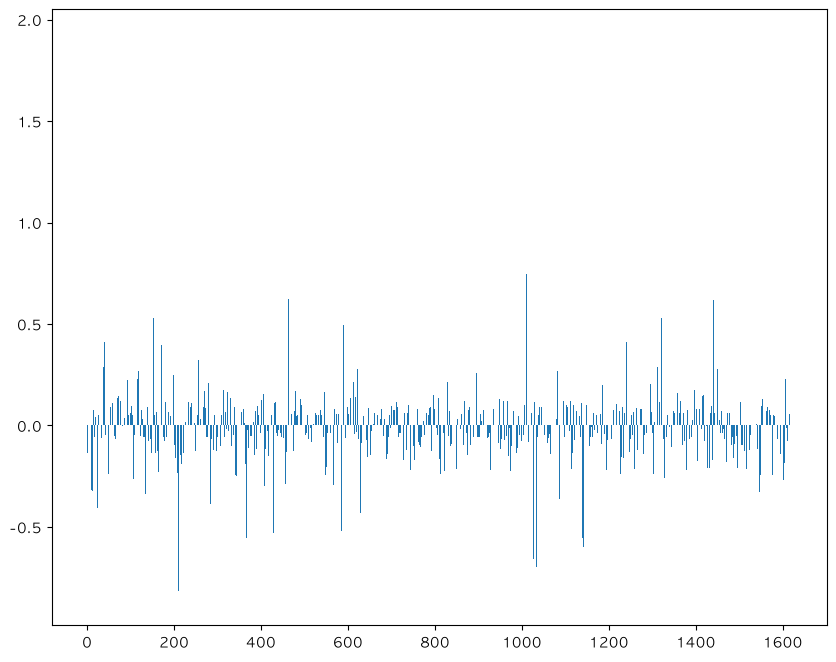

In [ ]:
plt.rcParams['figure.figsize']=[10,8]
plt.rcParams['axes.unicode_minus'] = False  #음수 기호 깨짐 방지
plt.bar(range(len(lr.coef_[0])),lr.coef_[0])

In [ ]:
l1 = [10,11,12,13,14,15]
for i,n in enumerate(l1) :  # enumerate(l1) : li리스트의 인덱스와 값을 리턴
    print(i,n)

0 10
1 11
2 12
3 13
4 14
5 15


In [82]:
#가중치 값으로 정렬하기
coef_pos_index = sorted(((value,index) for index,value in enumerate(lr.coef_[0])),reverse=True)
coef_pos_index[:10]

[(np.float64(1.9123417403297018), 605),
 (np.float64(0.7454604304487703), 1011),
 (np.float64(0.6239898377195616), 463),
 (np.float64(0.6159169703217977), 1441),
 (np.float64(0.531338589526035), 153),
 (np.float64(0.5277204550811788), 1321),
 (np.float64(0.4929709891647249), 590),
 (np.float64(0.48853634150918784), 809),
 (np.float64(0.48456038538211027), 1311),
 (np.float64(0.48261191290533634), 30)]

In [ ]:
#글뭉치 데이터에서 원래 데이터를 출력하기
invert_index_vectorizer = {v:k for k,v in index_vectorizer.vocabulary_.items()}
cnt = 0
for k,v in index_vectorizer.vocabulary_.items() :
    print(k,v)
    cnt += 1
    if cnt >= 10 :
        break

In [ ]:
#상위 20개의 긍정 단어(형태소) 출력하기
for coef in coef_pos_index[:20] :
    print(invert_index_vectorizer[coef[1]],coef[0])

In [ ]:
#하위 20개의 부정 단어(형태소) 출력하기
for coef in coef_pos_index[-20:] :
    print(invert_index_vectorizer[coef[1]],coef[0])

In [90]:
#명사 기준 긍정순 10개, 부정순 10  : 품사가  N으로 시작
#형용사 기준 긍정순 10개, 부정순 10 : VA 품사
noun_list = []
adj_list = []
for coef in coef_pos_index :
    category = invert_index_vectorizer[coef[1]].split("/")[1]
    if category.startswith('N') :
        noun_list.append((invert_index_vectorizer[coef[1]],coef[0]))
    elif category == 'VA' :
        adj_list.append((invert_index_vectorizer[coef[1]],coef[0]))

In [ ]:
#긍정 명사
print(noun_list[:10])
#긍정 형용사
print(adj_list[:10])

In [93]:
#부정 명사
print(noun_list[-10:])
#부정 형용사
print(adj_list[-10:])

[('것/NNB', np.float64(-0.3401199654462456)), ('예약/NNG', np.float64(-0.35040608167221104)), ('인분/NNB', np.float64(-0.37178777098244914)), ('가격/NNG', np.float64(-0.39561704650999485)), ('정도/NNG', np.float64(-0.39854200594379446)), ('최악/NNG', np.float64(-0.4085627920339727)), ('곱창/NNG', np.float64(-0.4190593781741177)), ('대비/NNG', np.float64(-0.5307114188368621)), ('점/NNG', np.float64(-0.6255473070946045)), ('거/NNB', np.float64(-0.749876411119473))]
[('싸/VA', np.float64(-0.1834001074655807)), ('적/VA', np.float64(-0.18794792934402207)), ('심하/VA', np.float64(-0.2203005932266787)), ('달/VA', np.float64(-0.23445147241638348)), ('있/VA', np.float64(-0.2372280916335396)), ('같/VA', np.float64(-0.26154676040471364)), ('느끼하/VA', np.float64(-0.28804140831164404)), ('맛없/VA', np.float64(-0.29716663823827566)), ('질기/VA', np.float64(-0.5242783901048833)), ('없/VA', np.float64(-0.6583828398338465))]


In [94]:
#성능 평가하기
from sklearn.metrics import confusion_matrix
confmat = confusion_matrix(y_test,y_pred)
print(confmat)

[[14 29]
 [ 0 49]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("정확도.accuracy: %.2f" % accuracy_score(y_test,y_pred))
print("정밀도.Precision : %.3f" % precision_score(y_test, y_pred))
print("재현율(민감도)Recall : %.3f" % recall_score(y_test, y_pred))
print("F1 score : %.3f" % f1_score(y_test, y_pred))

정확도.accuracy: 0.68
정밀도.Precision : 0.628
재현율(민감도)Recall : 1.000
F1 score : 0.772


### 퍼셉트론 : 인공 신경망의 단위
y = x1w1 + x2w2 + b

In [ ]:
#퍼셉트론 이용하여 AND 게이트 구현하기
import numpy as np
def AND(x1,x2) :
    x = np.array([x1,x2]) #입력값
    w = np.array([0.5,0.5]) #가중치
    b = -0.8  #편향
    tmp = np.sum(w*x) + b  #x[0]*w[0] + x[1]*w[1] + b = (1,1)=> 0.2
    if tmp <= 0 :
        return 0
    else :
        return 1

for xs in [(0,0),(0,1),(1,0),(1,1)] :
    y = AND(xs[0],xs[1])
    print(str(xs),"=>",y)

(0, 0) => 0
(0, 1) => 0
(1, 0) => 0
(1, 1) => 1


In [99]:
# OR 함수 구현하기
def OR(x1,x2) :
    x = np.array([x1,x2]) #입력값
    w = np.array([0.5,0.5]) #가중치
    b = -0.2  #편향
    tmp = np.sum(w*x) + b  #x[0]*w[0] + x[1]*w[1] + b = (1,1)=> 0.2
    if tmp <= 0 :
        return 0
    else :
        return 1
for xs in [(0,0),(0,1),(1,0),(1,1)] :
    y = OR(xs[0],xs[1])
    print(str(xs),"=>",y) 

(0, 0) => 0
(0, 1) => 1
(1, 0) => 1
(1, 1) => 1


In [100]:
# NAND 함수 구현하기
def NAND(x1,x2) :
    x = np.array([x1,x2]) #입력값
    w = np.array([-0.5,-0.5]) #가중치
    b = 0.8  #편향
    tmp = np.sum(w*x) + b  #x[0]*w[0] + x[1]*w[1] + b = (1,1)=> 0.2
    if tmp <= 0 :
        return 0
    else :
        return 1
    
for xs in [(0,0),(0,1),(1,0),(1,1)] :
    y = NAND(xs[0],xs[1])
    print(str(xs),"=>",y) 

(0, 0) => 1
(0, 1) => 1
(1, 0) => 1
(1, 1) => 0


In [101]:
#XOR 함수 생성하기
def XOR(x1,x2) :
    s1 = NAND(x1,x2)
    s2 = OR(x1,x2)
    y = AND(s1,s2)
    return y
for xs in [(0,0),(0,1),(1,0),(1,1)] :
    y = XOR(xs[0],xs[1])
    print(str(xs),"=>",y) 

(0, 0) => 0
(0, 1) => 1
(1, 0) => 1
(1, 1) => 0


In [ ]:
!pip3 install tensorflow

In [103]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
#현재 시스템 환경 CPU/GPU환경 여부 조회
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 17494596055537414535
 xla_global_id: -1]

In [ ]:
#Tensorflow를 이용하여 OR 구현하기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import mse

In [125]:
#tf.random.set_seed(777)
data = np.array([[0,0],[0,1],[1,0],[1,1]])  #학습데이터
label = np.array([[0],[1],[1],[1]])         #정답
model = Sequential()  #모델 생성
#activation='linear' : 활성화 함수. 
model.add(Dense(1,input_shape=(2,),activation='linear'))  #1층
#optimizer=SGD() : 경사하강법, 최적의 상태를 찾아가기 위한 함수. 일부 데이터만 추출하여 조금씩 이동 방법
#loss=mse : 평균제곱오차. 손실함수값이 작으면 성능이 좋다.  
# metrics=['acc'] : 평가지표. 정확도
model.compile(optimizer=SGD(), loss=mse,metrics=['acc'])
model.fit(data,label,epochs=500,verbose=0) #

In [126]:
print("가중치와 편향:",model.get_weights())
print('예측값:',model.predict(data))
print('평가:',model.evaluate(data,label))

가중치와 편향: [array([[0.56560206],
       [0.38059065]], dtype=float32), array([0.2819114], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
예측값: [[0.2819114 ]
 [0.66250205]
 [0.84751344]
 [1.2281041 ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 1.0000 - loss: 0.0672
평가: [0.06716563552618027, 1.0]


In [128]:
from tensorflow.keras.optimizers import Adam

# 1. OR 게이트 데이터 준비 (반드시 numpy 배열 형태여야 합니다)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

# 2. 모델 만들기 (입력 2개 -> 출력 1개, 시그모이드)
model = Sequential([Dense(1, input_shape=(2,), activation='sigmoid')])

# 3. 컴파일 (학습률 0.1, binary_crossentropy 조합)
model.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['acc'],
)

# 4. 학습하기 (500번 정도면 충분합니다)
model.fit(X, y, epochs=500, verbose=0)

# 5. 결과 확인
preds = model.predict(X)
print("예측 결과:")
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
예측 결과:
[[0.00936757]
 [0.9963707 ]
 [0.9959475 ]
 [0.9999999 ]]


In [124]:
print("가중치와 편향:",model.get_weights())
print('예측값:',model.predict(data))
print('평가:',model.evaluate(data,label))

가중치와 편향: [array([[8.313562 ],
       [7.6880627]], dtype=float32), array([-3.5128565], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
예측값: [[0.02894863]
 [0.9848607 ]
 [0.99184316]
 [0.99999624]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 1.0000 - loss: 0.0132
평가: [0.013206264935433865, 1.0]
